In [44]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt 
from tensorflow.keras.models import load_model
from tensorflow.keras.metrics import CategoricalAccuracy, Precision, Recall, F1Score, AUC
from tensorflow.keras.utils import to_categorical
from tensorflow.math import confusion_matrix
from pathlib import Path

In [24]:
DATAPATH = os.getcwd() / Path("../../data/processed")

X_test_pad_path = (DATAPATH / "X_test_pad.npy").resolve()
y_test_path = (DATAPATH / "y_test.npy").resolve()

X_test = np.load(X_test_pad_path)
y_test = np.load(y_test_path)

unique_classes, counts = np.unique(y_test, return_counts=True)
total = len(y_test)
n_classes = len(unique_classes)

y_test_oh = to_categorical(y_test, num_classes=n_classes)


In [9]:
model = load_model("lstm_review_classifier.keras")
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 200, 64)        │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 200, 128)       │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,248,331 (8.58 MB)

 Trainable params: 749,443 (2.86 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,498,888 (5.72 MB)

In [13]:
y_pred = model.predict(X_test)

33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step


In [29]:
def get_metrics(Metric, y_test, y_pred):
    m = Metric()
    m.update_state(y_test, y_pred)
    return m.result().numpy()

In [36]:
print("Accuracy", get_metrics(CategoricalAccuracy, y_test_oh, y_pred))
print("Precision", get_metrics(Precision, y_test_oh, y_pred))
print("Recall", get_metrics(Recall, y_test_oh, y_pred))
print("AUC", get_metrics(AUC, y_test_oh, y_pred))
print("F1", get_metrics(F1Score, y_test_oh, y_pred))

Accuracy 0.70666665
Precision 0.75986844
Recall 0.66
AUC 0.87424403
F1 [0.6763005 0.5482865 0.8075539]


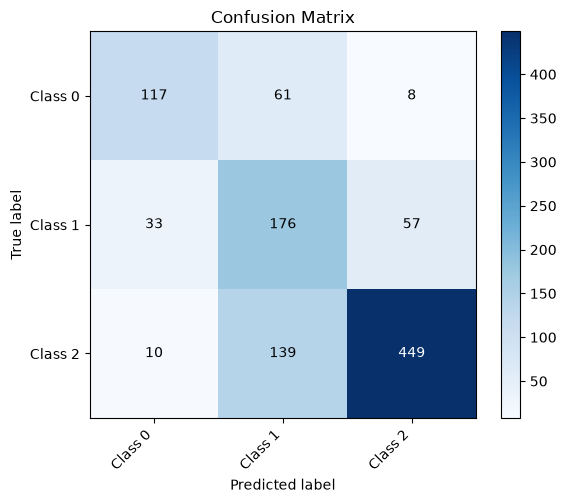

In [49]:
y_test_labels = tf.argmax(y_test_oh, axis=1)
y_pred_labels = tf.argmax(y_pred, axis=1)

cm = tf.math.confusion_matrix(y_test_labels, y_pred_labels, num_classes=n_classes).numpy()

class_names = [f"Class {i}" for i in range(n_classes)]

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap='Blues')

# Colorbar
fig.colorbar(im, ax=ax)

# Axis labels and ticks
ax.set_xticks(np.arange(n_classes))
ax.set_yticks(np.arange(n_classes))
ax.set_xticklabels(class_names)
ax.set_yticklabels(class_names)
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_title("Confusion Matrix")

# Rotate x labels if they're long
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

# Annotate each cell with its count
thresh = cm.max() / 2.0
for i in range(n_classes):
    for j in range(n_classes):
        ax.text(j, i, format(cm[i, j], 'd'),
                 ha="center", va="center",
                 color="white" if cm[i, j] > thresh else "black")

fig.tight_layout()
plt.show()